<a href="https://colab.research.google.com/github/Manishmaity/AI-ML-Based-Predictive-Maintenance-Vehicle-Health-Monitoring-System/blob/main/Predictive_Maintenance_Vehicle_Health_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI/ML-Based Predictive Maintenance & Vehicle Health Monitoring System
### Module 3 (Connectivity) Project — Option 1

**Goal:** Predict vehicle/component failure *before it occurs*, using onboard sensor data, and
output a Vehicle Health Score, a Failure Probability, and the top contributing factors.

**Pipeline (matches the project architecture):**
```
Vehicle Sensors → RPM | Temperature | Pressure | Vibration → Data Preprocessing
   → ML/DL Model → Failure Probability → Vehicle Health Score → Maintenance Alert
```

**Input features:** engine temperature, RPM, oil pressure, vibration, battery voltage,
coolant temperature, fuel consumption, vehicle speed, operating hours.

**This notebook:**
1. Generates a physically-motivated synthetic sensor dataset (drop in a real telemetry
   CSV instead if you have one — same column names, no other changes needed).
2. Trains and compares **Logistic Regression, Decision Tree, Random Forest, and XGBoost**
   classifiers for 3-class health status (Healthy / Warning / Critical), and times each
   one so you can see the accuracy-vs-efficiency trade-off.
3. Trains an **LSTM** on short sensor-history sequences, since real predictive maintenance
   uses trends over time, not just a single snapshot.
4. Builds a `diagnose_vehicle()` function that reproduces the brief's exact sample output
   format: `Vehicle Health: 72% | Failure Probability: 68% | Status: WARNING` + top factors.

> **Runtime:** CPU is enough for the classical models; GPU (Runtime → Change runtime type)
> speeds up the LSTM section but isn't required.

## 1. Setup

In [15]:
!pip install -q xgboost

In [16]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 2. Dataset

No telemetry dataset was provided, so this notebook **simulates realistic vehicle sensor
readings** using physically-motivated ranges and degradation patterns (higher vibration,
rising engine/coolant temperature, and dropping oil pressure as operating hours climb, with
noise). About 35% of samples are drawn as "degrading" vehicles so all 3 health classes
(Healthy / Warning / Critical) are represented.

> **Using real telemetry instead:** if you have real OBD-II / sensor-log data, just build a
> DataFrame `df` with the same 9 feature columns plus a `status` column, and skip straight to
> section 3 (Train/Test Split) — nothing else changes.

In [17]:
FEATURES = ["engine_temp", "rpm", "oil_pressure", "vibration", "battery_voltage",
            "coolant_temp", "fuel_consumption", "vehicle_speed", "operating_hours"]

def gen_row():
    engine_temp = rng.normal(90, 8)
    rpm = rng.normal(2200, 400)
    oil_pressure = rng.normal(45, 6)
    vibration = rng.normal(2.0, 0.6)
    battery_voltage = rng.normal(12.6, 0.3)
    coolant_temp = rng.normal(88, 7)
    fuel_consumption = rng.normal(8.0, 1.2)
    vehicle_speed = rng.normal(60, 20)
    operating_hours = rng.uniform(0, 5000)

    wear = operating_hours / 5000 * rng.uniform(0.3, 1.3)
    if rng.random() < 0.35:  # simulate a degrading vehicle
        vibration += wear * rng.uniform(2, 6)
        engine_temp += wear * rng.uniform(5, 20)
        oil_pressure -= wear * rng.uniform(5, 20)
        coolant_temp += wear * rng.uniform(3, 15)

    vibration = max(vibration, 0.1)
    oil_pressure = max(oil_pressure, 5)

    risk = 0.0
    risk += max(0, vibration - 3.0) * 0.15
    risk += max(0, engine_temp - 100) * 0.02
    risk += max(0, 45 - oil_pressure) * 0.02
    risk += max(0, coolant_temp - 100) * 0.015
    risk += max(0, operating_hours - 3000) / 3000 * 0.3
    risk += rng.normal(0, 0.05)
    risk = float(np.clip(risk, 0, 1.5))

    status = "Healthy" if risk < 0.25 else ("Warning" if risk < 0.6 else "Critical")

    return dict(engine_temp=engine_temp, rpm=rpm, oil_pressure=oil_pressure, vibration=vibration,
                battery_voltage=battery_voltage, coolant_temp=coolant_temp,
                fuel_consumption=fuel_consumption, vehicle_speed=vehicle_speed,
                operating_hours=operating_hours, risk=risk, status=status)

N = 6000
df = pd.DataFrame([gen_row() for _ in range(N)])
print("Dataset size:", len(df))
print(df["status"].value_counts())
df.to_csv("vehicle_sensor_dataset.csv", index=False)
df.head()

Dataset size: 6000
status
Healthy     4576
Warning      983
Critical     441
Name: count, dtype: int64


,engine_temp,rpm,oil_pressure,vibration,battery_voltage,coolant_temp,fuel_consumption,vehicle_speed,operating_hours,risk,status
0,92.437737,1784.006358,49.502707,2.564339,12.014689,78.884743,8.153408,53.675148,640.568163,0.038890,Healthy
1,90.528246,2650.896483,47.805056,1.484425,12.710625,81.287822,9.054140,59.001482,3790.438700,0.071317,Healthy
2,86.573377,2059.146580,48.193855,2.219266,12.723820,91.015747,10.569977,51.871700,1629.126791,0.056449,Healthy
3,89.088420,1863.937409,40.053113,2.390356,12.822976,91.802080,7.201388,64.643226,1937.391895,0.110118,Healthy
4,95.431309,2227.031628,46.734716,2.378773,12.162853,85.762301,7.435553,47.222443,698.984991,0.048414,Healthy


### 2.1 Exploratory Data Analysis

/tmp/ipykernel_1036/1588742160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="status", order=["Healthy", "Warning", "Critical"],


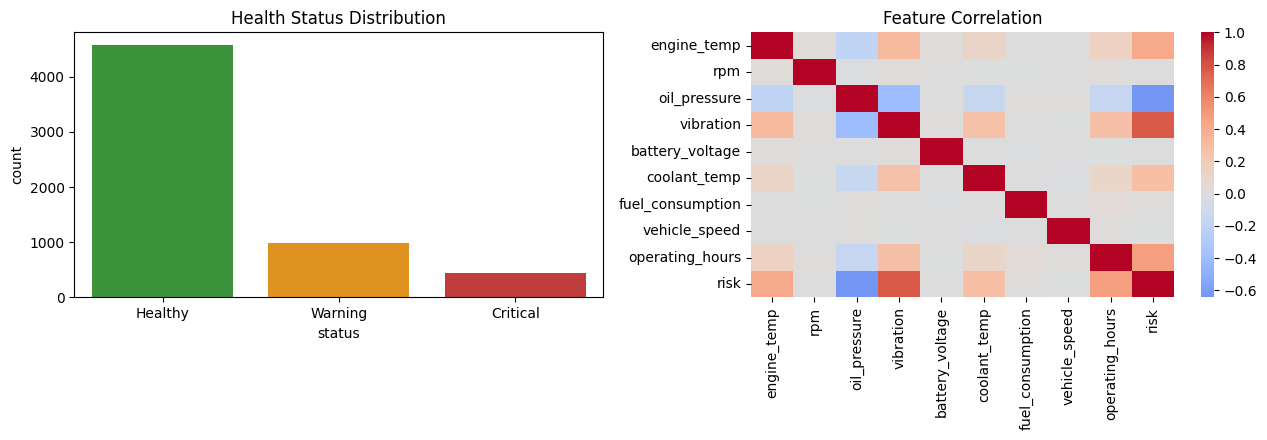

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x="status", order=["Healthy", "Warning", "Critical"],
              palette={"Healthy": "#2ca02c", "Warning": "#ff9800", "Critical": "#d62728"}, ax=axes[0])
axes[0].set_title("Health Status Distribution")

corr = df[FEATURES + ["risk"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Feature Correlation")

plt.tight_layout()
plt.show()

## 3. Train / Test Split

In [19]:
X = df[FEATURES]
y = df["status"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler().fit(Xtr)
Xtr_scaled = scaler.transform(Xtr)
Xte_scaled = scaler.transform(Xte)

le = LabelEncoder().fit(y)  # needed for XGBoost, which wants integer labels
ytr_enc, yte_enc = le.transform(ytr), le.transform(yte)

print("Train:", Xtr.shape, " Test:", Xte.shape)
print("Classes:", list(le.classes_))

Train: (4800, 9)  Test: (1200, 9)
Classes: ['Critical', 'Healthy', 'Warning']


## 4. Classical ML Models — Accuracy vs. Training Time

We train four classical models on the tabular sensor snapshot and time each one, so we can
compare **accuracy vs. efficiency** — important for a system that may need to run on
resource-constrained in-vehicle hardware.

In [20]:
results = []

def evaluate(name, model, Xtr_, Xte_, ytr_, yte_, label_names):
    t0 = time.time()
    model.fit(Xtr_, ytr_)
    train_time = time.time() - t0
    t0 = time.time()
    preds = model.predict(Xte_)
    infer_time_ms = (time.time() - t0) / len(Xte_) * 1000
    acc = accuracy_score(yte_, preds)
    f1 = f1_score(yte_, preds, average="macro")
    results.append({"model": name, "accuracy": acc, "f1_macro": f1,
                     "train_time_s": train_time, "inference_ms_per_sample": infer_time_ms})
    print(f"{name:18s} acc={acc:.3f}  f1_macro={f1:.3f}  train={train_time:.3f}s  "
          f"infer={infer_time_ms:.4f}ms/sample")
    return model, preds

log_reg, _          = evaluate("LogisticRegression", LogisticRegression(max_iter=500),
                                Xtr_scaled, Xte_scaled, ytr, yte, le.classes_)
dec_tree, _         = evaluate("DecisionTree", DecisionTreeClassifier(max_depth=8, random_state=SEED),
                                Xtr, Xte, ytr, yte, le.classes_)
rand_forest, rf_pred = evaluate("RandomForest", RandomForestClassifier(n_estimators=200, random_state=SEED),
                                Xtr, Xte, ytr, yte, le.classes_)
xgb_model, xgb_pred = evaluate("XGBoost", XGBClassifier(n_estimators=200, max_depth=5, eval_metric="mlogloss",
                                                          random_state=SEED),
                                Xtr, Xte, ytr_enc, yte_enc, le.classes_)

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
results_df

LogisticRegression acc=0.908  f1_macro=0.847  train=0.110s  infer=0.0004ms/sample
DecisionTree       acc=0.903  f1_macro=0.837  train=0.163s  infer=0.0019ms/sample
RandomForest       acc=0.928  f1_macro=0.890  train=8.909s  infer=0.0577ms/sample
XGBoost            acc=0.927  f1_macro=0.885  train=2.050s  infer=0.0430ms/sample


,model,accuracy,f1_macro,train_time_s,inference_ms_per_sample
2,RandomForest,0.928333,0.889809,8.909436,0.057715
3,XGBoost,0.926667,0.885008,2.049963,0.043039
0,LogisticRegression,0.908333,0.847344,0.110166,0.000419
1,DecisionTree,0.903333,0.837226,0.162962,0.001901


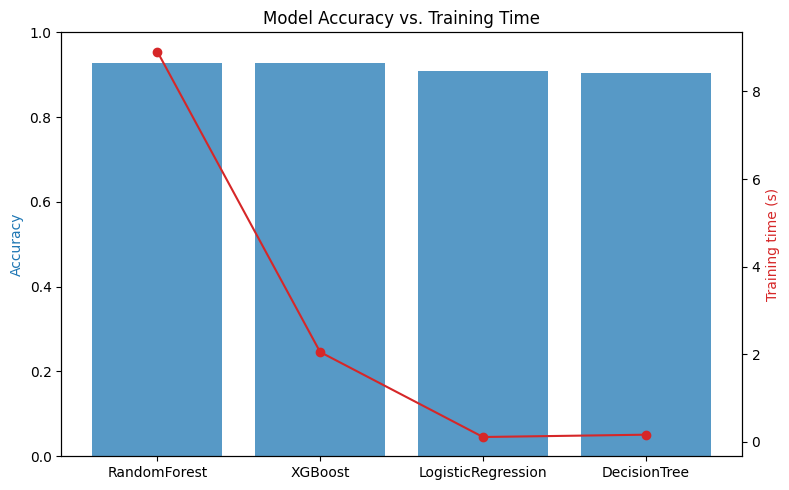

In [21]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.bar(results_df["model"], results_df["accuracy"], color="#1f77b4", alpha=0.75, label="Accuracy")
ax2.plot(results_df["model"], results_df["train_time_s"], color="#d62728", marker="o", label="Train time (s)")

ax1.set_ylabel("Accuracy", color="#1f77b4")
ax2.set_ylabel("Training time (s)", color="#d62728")
ax1.set_ylim(0, 1)
plt.title("Model Accuracy vs. Training Time")
fig.tight_layout()
plt.show()

In [22]:
best_row = results_df.iloc[0]
print(f"Most accurate model: {best_row['model']} (accuracy={best_row['accuracy']:.3f})")

fastest_row = results_df.sort_values('train_time_s').iloc[0]
print(f"Fastest to train: {fastest_row['model']} (train_time={fastest_row['train_time_s']:.3f}s, "
      f"accuracy={fastest_row['accuracy']:.3f})")

Most accurate model: RandomForest (accuracy=0.928)
Fastest to train: LogisticRegression (train_time=0.110s, accuracy=0.908)


### 4.1 Confusion Matrix — Random Forest

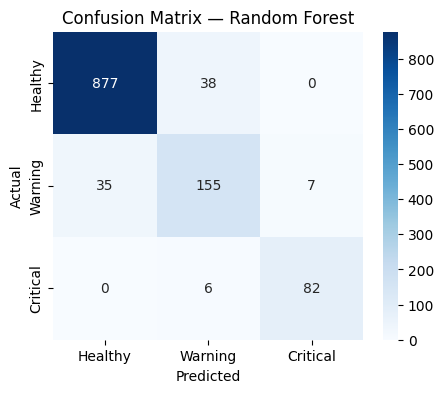

              precision    recall  f1-score   support

    Critical       0.92      0.93      0.93        88
     Healthy       0.96      0.96      0.96       915
     Warning       0.78      0.79      0.78       197

    accuracy                           0.93      1200
   macro avg       0.89      0.89      0.89      1200
weighted avg       0.93      0.93      0.93      1200



In [23]:
cm = confusion_matrix(yte, rf_pred, labels=["Healthy", "Warning", "Critical"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Healthy", "Warning", "Critical"],
            yticklabels=["Healthy", "Warning", "Critical"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.show()

print(classification_report(yte, rf_pred))

### 4.2 Top Contributing Factors

Feature importance from Random Forest / XGBoost tells us which sensors drive failure risk
the most — this becomes the "Major contributing factors" list in the final alert.

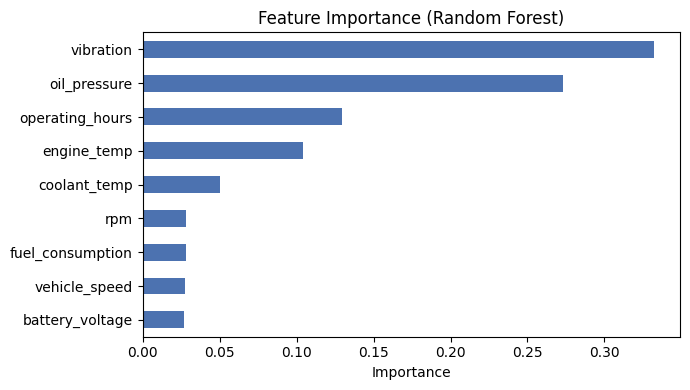

,0
vibration,0.332432
oil_pressure,0.272930
operating_hours,0.129349
engine_temp,0.103977
coolant_temp,0.050267
rpm,0.028481
fuel_consumption,0.028186
vehicle_speed,0.027737
battery_voltage,0.026641


In [24]:
importances = pd.Series(rand_forest.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importances.plot(kind="barh", color="#4c72b0")
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 5. Sequence Model — LSTM on Sensor History

A single snapshot misses *trends* (e.g. vibration climbing steadily over the last hour is
more worrying than one noisy spike). This section builds short synthetic sensor-history
sequences and trains an LSTM to predict the health status from the trend, not just the
latest reading.

In [25]:
SEQ_LEN = 10  # last 10 readings

def gen_sequence():
    """Simulate SEQ_LEN consecutive readings for one vehicle, with an evolving wear trend."""
    operating_hours = rng.uniform(0, 5000)
    degrading = rng.random() < 0.35
    wear_start = operating_hours / 5000 * rng.uniform(0.3, 1.3) if degrading else 0.0
    wear_end = wear_start + (rng.uniform(0.1, 0.5) if degrading else 0.0)
    wears = np.linspace(wear_start, wear_end, SEQ_LEN)

    seq = []
    last_risk = 0
    for wear in wears:
        engine_temp = rng.normal(90, 4) + wear * rng.uniform(5, 20)
        rpm = rng.normal(2200, 200)
        oil_pressure = max(rng.normal(45, 3) - wear * rng.uniform(5, 20), 5)
        vibration = max(rng.normal(2.0, 0.3) + wear * rng.uniform(2, 6), 0.1)
        battery_voltage = rng.normal(12.6, 0.2)
        coolant_temp = rng.normal(88, 4) + wear * rng.uniform(3, 15)
        fuel_consumption = rng.normal(8.0, 0.6)
        vehicle_speed = rng.normal(60, 10)

        risk = (max(0, vibration - 3.0) * 0.15 + max(0, engine_temp - 100) * 0.02 +
                max(0, 45 - oil_pressure) * 0.02 + max(0, coolant_temp - 100) * 0.015 +
                max(0, operating_hours - 3000) / 3000 * 0.3)
        last_risk = risk
        seq.append([engine_temp, rpm, oil_pressure, vibration, battery_voltage,
                    coolant_temp, fuel_consumption, vehicle_speed, operating_hours])

    status = "Healthy" if last_risk < 0.25 else ("Warning" if last_risk < 0.6 else "Critical")
    return np.array(seq, dtype=np.float32), status

N_SEQ = 3000
seqs, seq_labels = [], []
for _ in range(N_SEQ):
    s, lbl = gen_sequence()
    seqs.append(s)
    seq_labels.append(lbl)

seqs = np.stack(seqs)  # (N_SEQ, SEQ_LEN, 9)
seq_labels_enc = le.transform(seq_labels)
print("Sequence tensor shape:", seqs.shape)
print(pd.Series(seq_labels).value_counts())

Sequence tensor shape: (3000, 10, 9)
Healthy     2198
Warning      416
Critical     386
Name: count, dtype: int64


In [26]:
seq_train_idx, seq_test_idx = train_test_split(
    np.arange(len(seqs)), test_size=0.2, random_state=SEED, stratify=seq_labels_enc
)

# Scale using stats from the flattened training sequences
seq_scaler = StandardScaler().fit(seqs[seq_train_idx].reshape(-1, seqs.shape[-1]))

def scale_seq(batch):
    shp = batch.shape
    return seq_scaler.transform(batch.reshape(-1, shp[-1])).reshape(shp).astype(np.float32)

seqs_scaled = scale_seq(seqs)

class SensorSeqDataset(Dataset):
    def __init__(self, seqs, labels, idx):
        self.X = seqs[idx]
        self.y = labels[idx]
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i], dtype=torch.long)

train_loader = DataLoader(SensorSeqDataset(seqs_scaled, seq_labels_enc, seq_train_idx), batch_size=32, shuffle=True)
test_loader  = DataLoader(SensorSeqDataset(seqs_scaled, seq_labels_enc, seq_test_idx), batch_size=64)

class HealthLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=64, n_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, batch_first=True, num_layers=1)
        self.fc = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, n_classes))
    def forward(self, x):
        out, (h, c) = self.lstm(x)
        return self.fc(h[-1])

lstm_model = HealthLSTM(n_features=seqs.shape[-1]).to(DEVICE)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 15
t0 = time.time()
for epoch in range(EPOCHS):
    lstm_model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}  loss={total_loss/len(train_loader.dataset):.4f}")
lstm_train_time = time.time() - t0
print(f"LSTM training time: {lstm_train_time:.2f}s")

Epoch 1/15  loss=0.5974
Epoch 3/15  loss=0.2153
Epoch 6/15  loss=0.1049
Epoch 9/15  loss=0.0698
Epoch 12/15  loss=0.0611
Epoch 15/15  loss=0.0440
LSTM training time: 5.65s


In [27]:
lstm_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = lstm_model(xb.to(DEVICE))
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

lstm_acc = accuracy_score(all_true, all_preds)
lstm_f1 = f1_score(all_true, all_preds, average="macro")
print(f"LSTM test accuracy: {lstm_acc:.3f}  f1_macro: {lstm_f1:.3f}")
print(classification_report(all_true, all_preds, target_names=le.classes_))

results.append({"model": "LSTM (sequence)", "accuracy": lstm_acc, "f1_macro": lstm_f1,
                 "train_time_s": lstm_train_time, "inference_ms_per_sample": np.nan})
results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
results_df

LSTM test accuracy: 0.975  f1_macro: 0.957
              precision    recall  f1-score   support

    Critical       1.00      0.95      0.97        77
     Healthy       0.98      0.99      0.99       440
     Warning       0.90      0.92      0.91        83

    accuracy                           0.97       600
   macro avg       0.96      0.95      0.96       600
weighted avg       0.98      0.97      0.98       600



,model,accuracy,f1_macro,train_time_s,inference_ms_per_sample
4,LSTM (sequence),0.975000,0.957018,5.648576,NaN
2,RandomForest,0.928333,0.889809,8.909436,0.057715
3,XGBoost,0.926667,0.885008,2.049963,0.043039
0,LogisticRegression,0.908333,0.847344,0.110166,0.000419
1,DecisionTree,0.903333,0.837226,0.162962,0.001901


## 6. Inference: `diagnose_vehicle()`

Reproduces the project brief's exact sample output format using the Random Forest model
(best accuracy-for-cost trade-off from Section 4) plus the feature-importance ranking for
"major contributing factors".

In [28]:
NORMAL_RANGES = {
    "engine_temp": (75, 100), "oil_pressure": (35, 55), "vibration": (0, 3.0),
    "coolant_temp": (75, 98), "battery_voltage": (12.2, 13.0),
}

def diagnose_vehicle(sensor_reading: dict):
    """sensor_reading: dict with the 9 FEATURES keys -> returns health report dict."""
    x = pd.DataFrame([sensor_reading])[FEATURES]
    proba = rand_forest.predict_proba(x)[0]
    classes = rand_forest.classes_
    status = classes[np.argmax(proba)]

    # failure probability = P(Warning) + P(Critical)
    failure_idx = [i for i, c in enumerate(classes) if c != "Healthy"]
    failure_probability = float(np.sum(proba[failure_idx]))
    health_score = round((1 - failure_probability) * 100)

    # contributing factors: features that are both important AND currently out of normal range
    factors = []
    for feat, (lo, hi) in NORMAL_RANGES.items():
        val = sensor_reading[feat]
        if val < lo or val > hi:
            direction = "High" if val > hi else "Low"
            factors.append((importances[feat], f"{direction} {feat.replace('_', ' ')}"))
    factors = [f for _, f in sorted(factors, reverse=True)][:3]

    return {
        "Vehicle Health": f"{health_score}%",
        "Failure Probability": f"{round(failure_probability * 100)}%",
        "Status": status.upper(),
        "Major contributing factors": factors if factors else ["None — all readings normal"],
    }

# Example matching the project brief's degrading-vehicle scenario
example_reading = {
    "engine_temp": 104, "rpm": 2300, "oil_pressure": 30, "vibration": 4.8,
    "battery_voltage": 12.4, "coolant_temp": 102, "fuel_consumption": 8.5,
    "vehicle_speed": 65, "operating_hours": 4200,
}
report = diagnose_vehicle(example_reading)
for k, v in report.items():
    print(f"{k}: {v}")

Vehicle Health: 0%
Failure Probability: 100%
Status: CRITICAL
Major contributing factors: ['High vibration', 'Low oil pressure', 'High engine temp']


## 7. Conclusion & Next Steps

- **Classical models (Section 4)** are extremely cheap to train (fractions of a second to a
  few seconds) and already reach strong accuracy on snapshot data — a good fit for
  lightweight, always-on in-vehicle inference.
- **The LSTM (Section 5)** trades more training time for the ability to catch *trends*
  (e.g. slowly rising vibration) that a single-snapshot model would miss — closer to how
  real predictive-maintenance systems work.
- **Next steps for a stronger submission:**
  - Swap the synthetic generator for real OBD-II / telematics data if available.
  - Add a regression head that predicts *remaining useful life* (in hours) instead of just
    a 3-class status.
  - Add SHAP/XAI (as named in the brief) to explain individual predictions, not just global
    feature importance.
  - Wrap `diagnose_vehicle()` behind a small API/dashboard for a live maintenance-alert demo.